In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Keeping the seed fixed so I get the same results when I rerun the notebook
torch.manual_seed(21)
np.random.seed(21)

In [2]:
# Creating a nonlinear regression dataset using 3 input variables
def create_regression_data(sample_count=6200, noise_level=0.07, seed_value=21):
    rng = np.random.default_rng(seed_value)

    input_1 = rng.uniform(-2.8, 2.8, size=(sample_count, 1))
    input_2 = rng.uniform(-2.6, 2.6, size=(sample_count, 1))
    input_3 = rng.uniform(-2.4, 2.4, size=(sample_count, 1))

    # Slightly changing the target equation so this notebook is not identical
    target = (
        np.sin(1.15 * input_1)
        + 0.42 * (input_2 ** 2)
        - 0.55 * np.cos(1.6 * input_3)
        + 0.24 * (input_1 * input_2)
        - 0.16 * (input_2 * input_3)
        + 0.10 * (input_1 ** 2)
    )

    # Adding a little noise so the regression problem is not too perfect
    target = target + rng.normal(0.0, noise_level, size=target.shape)

    features = np.concatenate([input_1, input_2, input_3], axis=1).astype(np.float32)
    target = target.astype(np.float32)

    return features, target

X_data, y_data = create_regression_data()

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_data, y_data, test_size=0.2, random_state=21
)

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: torch.Size([4960, 3])
y_train shape: torch.Size([4960, 1])
X_test shape: torch.Size([1240, 3])
y_test shape: torch.Size([1240, 1])


In [3]:
# Building the network using PyTorch's built-in module style
class RegressionNet(nn.Module):
    def __init__(self, input_dim=3, hidden_dim_1=64, hidden_dim_2=32, output_dim=1):
        super().__init__()

        self.layer_1 = nn.Linear(input_dim, hidden_dim_1)
        self.layer_2 = nn.Linear(hidden_dim_1, hidden_dim_2)
        self.output_layer = nn.Linear(hidden_dim_2, output_dim)
        self.activation = nn.Tanh()

    def forward(self, x):
        x = self.activation(self.layer_1(x))
        x = self.activation(self.layer_2(x))
        x = self.output_layer(x)
        return x

model = RegressionNet()
print(model)

RegressionNet(
  (layer_1): Linear(in_features=3, out_features=64, bias=True)
  (layer_2): Linear(in_features=64, out_features=32, bias=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
  (activation): Tanh()
)


In [4]:
# Using MSE loss for training and Adam as the optimizer
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.008)

In [5]:
# Using MSE loss for training and Adam as the optimizer
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.008)

In [6]:
# This function is just to compute MAE at the end for one extra comparison
def mean_absolute_error(predicted_output, true_output):
    return torch.mean(torch.abs(predicted_output - true_output))

In [7]:
epochs = 320

train_loss_history = []
test_loss_history = []

# Training the model
for epoch in range(1, epochs + 1):
    model.train()

    predicted_train = model(X_train)
    train_loss = loss_function(predicted_train, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        predicted_test = model(X_test)
        test_loss = loss_function(predicted_test, y_test)

    train_loss_history.append(train_loss.item())
    test_loss_history.append(test_loss.item())

    if epoch == 1 or epoch % 25 == 0:
        print(f"Epoch {epoch:3d} | Train MSE: {train_loss.item():.6f} | Test MSE: {test_loss.item():.6f}")

Epoch   1 | Train MSE: 3.897201 | Test MSE: 2.679566
Epoch  25 | Train MSE: 1.374086 | Test MSE: 1.273042
Epoch  50 | Train MSE: 0.584379 | Test MSE: 0.509901
Epoch  75 | Train MSE: 0.149689 | Test MSE: 0.124923
Epoch 100 | Train MSE: 0.044822 | Test MSE: 0.039451
Epoch 125 | Train MSE: 0.020301 | Test MSE: 0.018099
Epoch 150 | Train MSE: 0.013258 | Test MSE: 0.012179
Epoch 175 | Train MSE: 0.010557 | Test MSE: 0.009827
Epoch 200 | Train MSE: 0.009322 | Test MSE: 0.008695
Epoch 225 | Train MSE: 0.008485 | Test MSE: 0.007805
Epoch 250 | Train MSE: 0.007616 | Test MSE: 0.007267
Epoch 275 | Train MSE: 0.016963 | Test MSE: 0.017207
Epoch 300 | Train MSE: 0.006973 | Test MSE: 0.007298


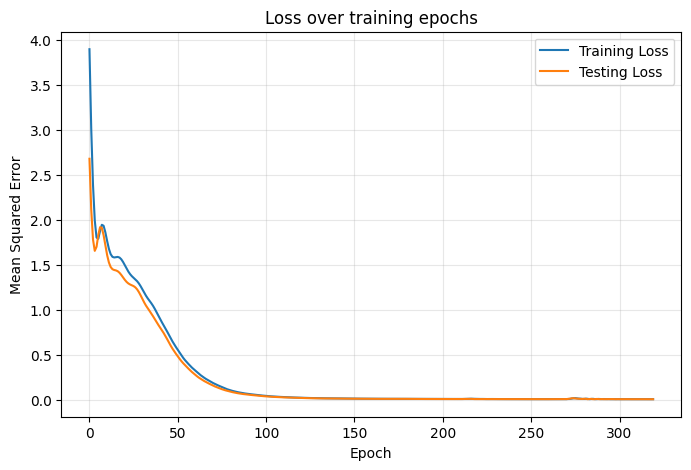

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label="Training Loss")
plt.plot(test_loss_history, label="Testing Loss")
plt.title("Loss over training epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
model.eval()
with torch.no_grad():
    final_test_predictions = model(X_test)

final_mse = loss_function(final_test_predictions, y_test).item()
final_mae = mean_absolute_error(final_test_predictions, y_test).item()

print("Final Test MSE:", round(final_mse, 6))
print("Final Test MAE:", round(final_mae, 6))

Final Test MSE: 0.006281
Final Test MAE: 0.063498


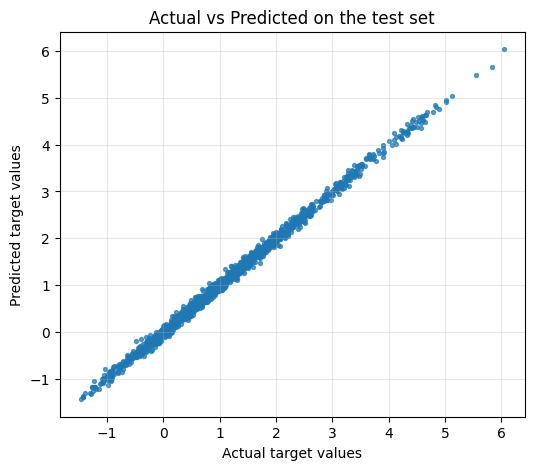

In [10]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test.squeeze().numpy(), final_test_predictions.squeeze().numpy(), s=8, alpha=0.7)
plt.xlabel("Actual target values")
plt.ylabel("Predicted target values")
plt.title("Actual vs Predicted on the test set")
plt.grid(alpha=0.3)
plt.show()

### Final Observation
In this notebook, I built the same 3-layer nonlinear regression model using PyTorch's built-in module functionality. Compared to the from-scratch version, this approach is much shorter and cleaner because PyTorch handles the layer definitions and automatic backpropagation for us.